# LSTM AE on Hanoi Dataset

- We use scenario 210 for the training data since it has no leaks.
- The Hanoi WDN has several pressure and flow sensors, as well as demand patterns for each node. In this model, we use the inlet flow sensor (Link_1) and all the pressure sensors (with the exception of Node_1 which is always 0)
- All sensor files were been pre-processed into a suitable format. The resultant CSVs are found in the same folder as this notebook. *If you're interested, you can see the pre-processing code under data_aggregator.ipynb*


In [ ]:
# import needed libraries - not all are used in this example
import torch
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pylab import rcParams
from matplotlib import rc
from sklearn.preprocessing import MinMaxScaler
from pandas.plotting import register_matplotlib_converters
from torch import nn, optim
from sklearn.model_selection import train_test_split
import argparse
import torch.nn.functional as F
from torchvision import datasets, transforms, models
import time

%matplotlib inline
%config InlineBackend.figure_format='retina'
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#93D30C", "#8F00FF"]
sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))
rcParams['figure.figsize'] = 12,8
register_matplotlib_converters()

RANDOM_SEED = 42 # important for reproducibility
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

## Load Data

We train on Scenario 210 because it has no leaks, and is hence 'normal' in nature

In [2]:
# read in training pressure file
pressure_data_train = pd.read_csv('Scenario-210_pressures.csv')

del pressure_data_train['Node_1']
pressure_data_train.head()

,Timestamp,Index,Node_21,Node_20,Node_8,Node_22,Node_23,Node_9,Node_27,Node_32,...,Node_17,Node_16,Node_4,Node_12,Node_13,Node_5,Node_7,Node_11,Node_10,Node_6
0,2017-01-01 00:00:00,1,67.721,68.047,67.771,67.469,67.769,67.713,67.355,67.266,...,67.572,67.416,68.250,67.580,67.434,68.091,67.827,67.630,67.685,67.875
1,2017-01-01 00:30:00,2,68.121,68.398,68.180,67.922,68.173,68.135,67.811,67.767,...,67.963,67.855,68.563,68.033,67.924,68.436,68.224,68.071,68.112,68.261
2,2017-01-01 01:00:00,3,68.464,68.697,68.496,68.317,68.519,68.456,68.218,68.156,...,68.326,68.233,68.823,68.367,68.281,68.717,68.535,68.399,68.436,68.568
3,2017-01-01 01:30:00,4,68.764,68.925,68.761,68.641,68.771,68.727,68.503,68.484,...,68.616,68.536,69.028,68.647,68.569,68.941,68.793,68.677,68.710,68.819
4,2017-01-01 02:00:00,5,68.888,69.047,68.905,68.777,68.910,68.876,68.701,68.653,...,68.799,68.725,69.142,68.806,68.738,69.065,68.933,68.832,68.861,68.957


In [3]:
# adding in training flow sensor data
flow_data_train = pd.read_csv('Scenario-210_flows.csv')
pressure_data_train['Link_1'] = flow_data_train['Link_1']

pressure_data_train = pressure_data_train.set_index('Timestamp')

# transform data file index to datetime and sort in chronological order
pressure_data_train.index = pd.to_datetime(pressure_data_train.index, format='%Y-%m-%d %H:%M:%S')
pressure_data_train = pressure_data_train.sort_index()

pressure_data_train.head()

,Index,Node_21,Node_20,Node_8,Node_22,Node_23,Node_9,Node_27,Node_32,Node_26,...,Node_16,Node_4,Node_12,Node_13,Node_5,Node_7,Node_11,Node_10,Node_6,Link_1
Timestamp,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,1,67.721,68.047,67.771,67.469,67.769,67.713,67.355,67.266,67.387,...,67.416,68.250,67.580,67.434,68.091,67.827,67.630,67.685,67.875,3384.0
2017-01-01 00:30:00,2,68.121,68.398,68.180,67.922,68.173,68.135,67.811,67.767,67.838,...,67.855,68.563,68.033,67.924,68.436,68.224,68.071,68.112,68.261,3045.6
2017-01-01 01:00:00,3,68.464,68.697,68.496,68.317,68.519,68.456,68.218,68.156,68.247,...,68.233,68.823,68.367,68.281,68.717,68.535,68.399,68.436,68.568,2728.8
2017-01-01 01:30:00,4,68.764,68.925,68.761,68.641,68.771,68.727,68.503,68.484,68.535,...,68.536,69.028,68.647,68.569,68.941,68.793,68.677,68.710,68.819,2469.6
2017-01-01 02:00:00,5,68.888,69.047,68.905,68.777,68.910,68.876,68.701,68.653,68.723,...,68.725,69.142,68.806,68.738,69.065,68.933,68.832,68.861,68.957,2300.4


In [4]:
pressure_data_train.shape

(17520, 33)

In [5]:
pressure_data_train.describe()

,Index,Node_21,Node_20,Node_8,Node_22,Node_23,Node_9,Node_27,Node_32,Node_26,...,Node_16,Node_4,Node_12,Node_13,Node_5,Node_7,Node_11,Node_10,Node_6,Link_1
count,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,...,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000
mean,8760.500000,63.845285,64.863483,64.111541,63.187285,64.174330,63.961349,63.066069,62.890264,63.177572,...,63.188812,65.382617,63.618057,63.234728,64.962065,64.258095,63.750391,63.886814,64.382532,5481.272671
std,5057.732694,3.065506,2.527114,2.895954,3.395475,2.858748,2.968182,3.390546,3.469824,3.337035,...,3.330341,2.270128,3.133334,3.325882,2.477995,2.824840,3.068529,3.004069,2.763664,1599.489697
min,1.000000,52.687000,55.825000,53.759000,50.880000,53.982000,53.348000,50.928000,50.507000,51.236000,...,51.243000,57.260000,52.392000,51.220000,56.088000,54.150000,52.767000,53.139000,54.492000,2167.200000
25%,4380.750000,61.755750,63.141750,62.143000,60.869750,62.225750,61.942750,60.758000,60.524000,60.905000,...,60.920750,63.837750,61.490000,60.976250,63.277750,62.340750,61.665000,61.843750,62.506000,4215.600000
50%,8760.500000,63.631000,64.691000,63.921000,62.952500,63.986000,63.767000,62.846500,62.665000,62.964500,...,62.970500,65.233000,63.411000,63.015000,64.800000,64.073000,63.549000,63.690000,64.201000,5778.000000
75%,13140.250000,66.510250,67.054250,66.616500,66.136250,66.645250,66.528500,65.990500,65.883250,66.061250,...,66.063000,67.348500,66.328000,66.111000,67.108000,66.701250,66.404000,66.485000,66.772500,6632.100000
max,17520.000000,69.029000,69.153000,69.021000,68.934000,69.029000,68.993000,68.834000,68.803000,68.857000,...,68.853000,69.235000,68.926000,68.868000,69.166000,69.048000,68.951000,68.980000,69.069000,9784.800000


We will test on Scenario 4, but for your final code, I expect it to be able to handle all provided scenarios well

In [6]:
# read in testing pressure file
pressure_data_test = pd.read_csv('Scenario-4_pressures.csv')

del pressure_data_test['Node_1']
pressure_data_test.head()

,Timestamp,Index,Node_21,Node_20,Node_8,Node_22,Node_23,Node_9,Node_27,Node_32,...,Node_17,Node_16,Node_4,Node_12,Node_13,Node_5,Node_7,Node_11,Node_10,Node_6
0,2017-01-01 00:00:00,1,67.762,68.026,67.789,67.623,67.881,67.753,67.321,67.299,...,67.627,67.449,68.334,67.657,67.351,68.095,67.846,67.700,67.730,67.936
1,2017-01-01 00:30:00,2,68.200,68.394,68.160,68.099,68.277,68.129,67.787,67.795,...,67.989,67.854,68.625,68.051,67.809,68.425,68.211,68.085,68.109,68.290
2,2017-01-01 01:00:00,3,68.575,68.726,68.550,68.491,68.635,68.526,68.255,68.255,...,68.435,68.312,68.910,68.461,68.244,68.754,68.589,68.490,68.509,68.650
3,2017-01-01 01:30:00,4,68.744,68.875,68.701,68.675,68.799,68.679,68.463,68.496,...,68.610,68.510,69.032,68.622,68.425,68.889,68.737,68.648,68.665,68.793
4,2017-01-01 02:00:00,5,68.947,69.054,68.908,68.883,68.989,68.890,68.718,68.724,...,68.839,68.750,69.185,68.845,68.702,69.066,68.937,68.865,68.878,68.985


In [7]:
# adding in testing flow sensor data
flow_data_test = pd.read_csv('Scenario-4_flows.csv')
pressure_data_test['Link_1'] = flow_data_test['Link_1']

pressure_data_test = pressure_data_test.set_index('Timestamp')

# transform data file index to datetime and sort in chronological order
pressure_data_test.index = pd.to_datetime(pressure_data_test.index, format='%Y-%m-%d %H:%M:%S')
pressure_data_test = pressure_data_test.sort_index()

pressure_data_test.head()

,Index,Node_21,Node_20,Node_8,Node_22,Node_23,Node_9,Node_27,Node_32,Node_26,...,Node_16,Node_4,Node_12,Node_13,Node_5,Node_7,Node_11,Node_10,Node_6,Link_1
Timestamp,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,1,67.762,68.026,67.789,67.623,67.881,67.753,67.321,67.299,67.333,...,67.449,68.334,67.657,67.351,68.095,67.846,67.700,67.730,67.936,3315.6
2017-01-01 00:30:00,2,68.200,68.394,68.160,68.099,68.277,68.129,67.787,67.795,67.806,...,67.854,68.625,68.051,67.809,68.425,68.211,68.085,68.109,68.290,2995.2
2017-01-01 01:00:00,3,68.575,68.726,68.550,68.491,68.635,68.526,68.255,68.255,68.265,...,68.312,68.910,68.461,68.244,68.754,68.589,68.490,68.509,68.650,2653.2
2017-01-01 01:30:00,4,68.744,68.875,68.701,68.675,68.799,68.679,68.463,68.496,68.478,...,68.510,69.032,68.622,68.425,68.889,68.737,68.648,68.665,68.793,2476.8
2017-01-01 02:00:00,5,68.947,69.054,68.908,68.883,68.989,68.890,68.718,68.724,68.727,...,68.750,69.185,68.845,68.702,69.066,68.937,68.865,68.878,68.985,2257.2


In [8]:
pressure_data_test.shape

(17520, 33)

In [9]:
pressure_data_test.describe()

,Index,Node_21,Node_20,Node_8,Node_22,Node_23,Node_9,Node_27,Node_32,Node_26,...,Node_16,Node_4,Node_12,Node_13,Node_5,Node_7,Node_11,Node_10,Node_6,Link_1
count,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,...,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000
mean,8760.500000,63.630346,64.421430,63.759174,63.253419,64.000981,63.645398,62.316457,62.182514,62.370975,...,62.609265,65.313104,63.370256,62.611662,64.649701,63.935509,63.486662,63.569758,64.197932,5574.169932
std,5057.732694,3.237459,2.808904,3.115977,3.432290,3.025340,3.176569,3.897862,3.976018,3.863975,...,3.780183,2.340121,3.316929,3.683464,2.668904,3.024398,3.259240,3.217467,2.893925,1658.559574
min,1.000000,52.150000,54.414000,52.911000,51.066000,53.202000,52.604000,48.474000,47.825000,48.486000,...,47.574000,57.056000,51.832000,49.590000,55.256000,53.378000,52.161000,52.401000,54.067000,2124.000000
25%,4380.750000,61.414750,62.494750,61.663000,60.907000,61.927750,61.510750,59.685000,59.462750,59.729000,...,60.159000,63.715750,61.141000,60.122750,62.837750,61.893750,61.301000,61.413000,62.237000,4273.200000
50%,8760.500000,63.393500,64.227000,63.579000,63.001000,63.788500,63.465000,62.078500,61.890000,62.112500,...,62.415000,65.168000,63.182500,62.394000,64.489500,63.759000,63.303000,63.390000,64.027500,5880.600000
75%,13140.250000,66.471250,66.875000,66.425250,66.274250,66.651000,66.362000,65.676250,65.680250,65.743750,...,65.835750,67.321250,66.209000,65.773500,66.932000,66.523000,66.274250,66.320000,66.674000,6772.500000
max,17520.000000,69.074000,69.163000,69.028000,69.023000,69.104000,69.012000,68.865000,68.864000,68.875000,...,68.889000,69.276000,68.972000,68.857000,69.169000,69.054000,68.989000,69.002000,69.097000,9997.200000


## Normalise the dataset
Normalisation is necessary to account for change in demand patterns throughout the year (they rise steadily from end of June, and drop back down after the summer)

We had to create our own "better" z-score normalisation function, coz otherwise we'd lose one period worth of data (in our case, the first month). The min_periods function allows us to calculate the z-score on less data than the period, which then gives us data from the second data point, and not after the 1440th i.e. after 1 month (or whatever window size we pass in).

I have left the standard zscore function in here for your own reference. We do not use it, as we work with the better one.

In [10]:
# define moving z-score standardization function
def zscore(x, window):
    r = x.rolling(window=window)
    m = r.mean().shift(1)
    s = r.std(ddof=0).shift(1)
    z = (x-m)/s
    return z

# better z-score function coz reduces amount of data lost due to rolling window
def zscore_better(x, period):
    # Calculate the rolling mean for the given period
    rolling_mean = x.rolling(window=period, min_periods=1).mean()     # min_periods=1 ensures that the first month of values is not NaN 
    # Calculate the rolling standard deviation for the given period
    rolling_std = x.rolling(window=period, min_periods=1).std()       
    # Compute the Z-scores for the close prices
    z_scores = (x - rolling_mean) / rolling_std
    return z_scores

In [ ]:
# calcular daily z-score for each train column
for column in pressure_data_train:
    # print(pressure_data[column])
    pressure_data_train[column] = zscore_better(pressure_data_train[column], 1440) #roughly 1-month window

pressure_data_train.head()

,Index,Node_21,Node_20,Node_8,Node_22,Node_23,Node_9,Node_27,Node_32,Node_26,...,Node_16,Node_4,Node_12,Node_13,Node_5,Node_7,Node_11,Node_10,Node_6,Link_1
Timestamp,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01 00:30:00,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,...,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,-0.707107
2017-01-01 01:00:00,1.000000,0.973474,0.972297,0.954627,0.976440,0.973253,0.951762,0.980547,0.955534,0.983330,...,0.974207,0.967789,0.946000,0.943788,0.964243,0.957159,0.947615,0.951305,0.959924,-0.988832
2017-01-01 01:30:00,1.161895,1.105383,1.073445,1.076739,1.093758,1.064404,1.075290,1.063147,1.078905,1.067045,...,1.086392,1.076317,1.067693,1.056763,1.075182,1.076901,1.071862,1.075204,1.076455,-1.105292
2017-01-01 02:00:00,1.264911,1.038875,1.045214,1.055167,1.029305,1.040122,1.056229,1.076624,1.048644,1.068979,...,1.084740,1.055521,1.054891,1.049140,1.054380,1.054537,1.055883,1.056628,1.055594,-1.110257


In [ ]:
# drop rows with NaN values (only 1 row thanks to our better z-score function)
pressure_data_train = pressure_data_train.dropna(how='all')
pressure_data_train.head()

,Index,Node_21,Node_20,Node_8,Node_22,Node_23,Node_9,Node_27,Node_32,Node_26,...,Node_16,Node_4,Node_12,Node_13,Node_5,Node_7,Node_11,Node_10,Node_6,Link_1
Timestamp,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:30:00,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,...,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,-0.707107
2017-01-01 01:00:00,1.000000,0.973474,0.972297,0.954627,0.976440,0.973253,0.951762,0.980547,0.955534,0.983330,...,0.974207,0.967789,0.946000,0.943788,0.964243,0.957159,0.947615,0.951305,0.959924,-0.988832
2017-01-01 01:30:00,1.161895,1.105383,1.073445,1.076739,1.093758,1.064404,1.075290,1.063147,1.078905,1.067045,...,1.086392,1.076317,1.067693,1.056763,1.075182,1.076901,1.071862,1.075204,1.076455,-1.105292
2017-01-01 02:00:00,1.264911,1.038875,1.045214,1.055167,1.029305,1.040122,1.056229,1.076624,1.048644,1.068979,...,1.084740,1.055521,1.054891,1.049140,1.054380,1.054537,1.055883,1.056628,1.055594,-1.110257
2017-01-01 02:30:00,1.336306,1.014262,0.994706,0.984404,0.990493,0.987311,0.984168,0.994578,0.966087,0.987868,...,1.005584,0.992496,0.987646,0.978278,0.988036,0.984918,0.986242,0.984727,0.984797,-1.041452


In [ ]:
# calcular daily z-score for each test column
for column in pressure_data_test:
    # print(pressure_data[column])
    pressure_data_test[column] = zscore_better(pressure_data_test[column], 1440) #roughly 1-month window

pressure_data_test.head()

,Index,Node_21,Node_20,Node_8,Node_22,Node_23,Node_9,Node_27,Node_32,Node_26,...,Node_16,Node_4,Node_12,Node_13,Node_5,Node_7,Node_11,Node_10,Node_6,Link_1
Timestamp,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01 00:30:00,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,...,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,-0.707107
2017-01-01 01:00:00,1.000000,0.973196,0.982424,1.008218,0.966235,0.982785,1.008932,1.000713,0.987214,0.994955,...,1.019830,0.996510,1.006567,0.991305,0.999494,1.005781,1.008331,1.008864,1.002789,-1.010690
2017-01-01 01:30:00,1.161895,0.971668,0.979489,0.978318,0.972079,0.983328,0.978207,0.994454,1.011510,0.996726,...,1.006721,0.984315,0.979124,0.974950,0.979989,0.977967,0.979623,0.980038,0.977647,-1.030265
2017-01-01 02:00:00,1.264911,1.066074,1.073928,1.087791,1.057052,1.071833,1.088571,1.093212,1.068763,1.088911,...,1.100624,1.084052,1.092602,1.118859,1.085354,1.085268,1.090449,1.089490,1.084950,-1.147965


In [14]:
# drop rows with NaN values
pressure_data_test = pressure_data_test.dropna(how='all')
pressure_data_test.head()

,Index,Node_21,Node_20,Node_8,Node_22,Node_23,Node_9,Node_27,Node_32,Node_26,...,Node_16,Node_4,Node_12,Node_13,Node_5,Node_7,Node_11,Node_10,Node_6,Link_1
Timestamp,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:30:00,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,...,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,0.707107,-0.707107
2017-01-01 01:00:00,1.000000,0.973196,0.982424,1.008218,0.966235,0.982785,1.008932,1.000713,0.987214,0.994955,...,1.019830,0.996510,1.006567,0.991305,0.999494,1.005781,1.008331,1.008864,1.002789,-1.010690
2017-01-01 01:30:00,1.161895,0.971668,0.979489,0.978318,0.972079,0.983328,0.978207,0.994454,1.011510,0.996726,...,1.006721,0.984315,0.979124,0.974950,0.979989,0.977967,0.979623,0.980038,0.977647,-1.030265
2017-01-01 02:00:00,1.264911,1.066074,1.073928,1.087791,1.057052,1.071833,1.088571,1.093212,1.068763,1.088911,...,1.100624,1.084052,1.092602,1.118859,1.085354,1.085268,1.090449,1.089490,1.084950,-1.147965
2017-01-01 02:30:00,1.336306,1.044125,1.046820,1.048386,1.046907,1.043450,1.049346,1.056166,1.035364,1.060306,...,1.054974,1.046396,1.058631,1.089966,1.046062,1.046263,1.053651,1.052463,1.045833,-1.111369


In [15]:
train = pressure_data_train
test = pressure_data_test
print(train.shape, test.shape)

(17519, 33) (17519, 33)


## Visualization 
To compare if there is a visible difference between the train & test data

Scenario 4 has a leak on Node 14. As per the Hanoi WDN layout, the nearest sensors are 9, 10, 15 and 16...so we'll constrain our visualisations to just those

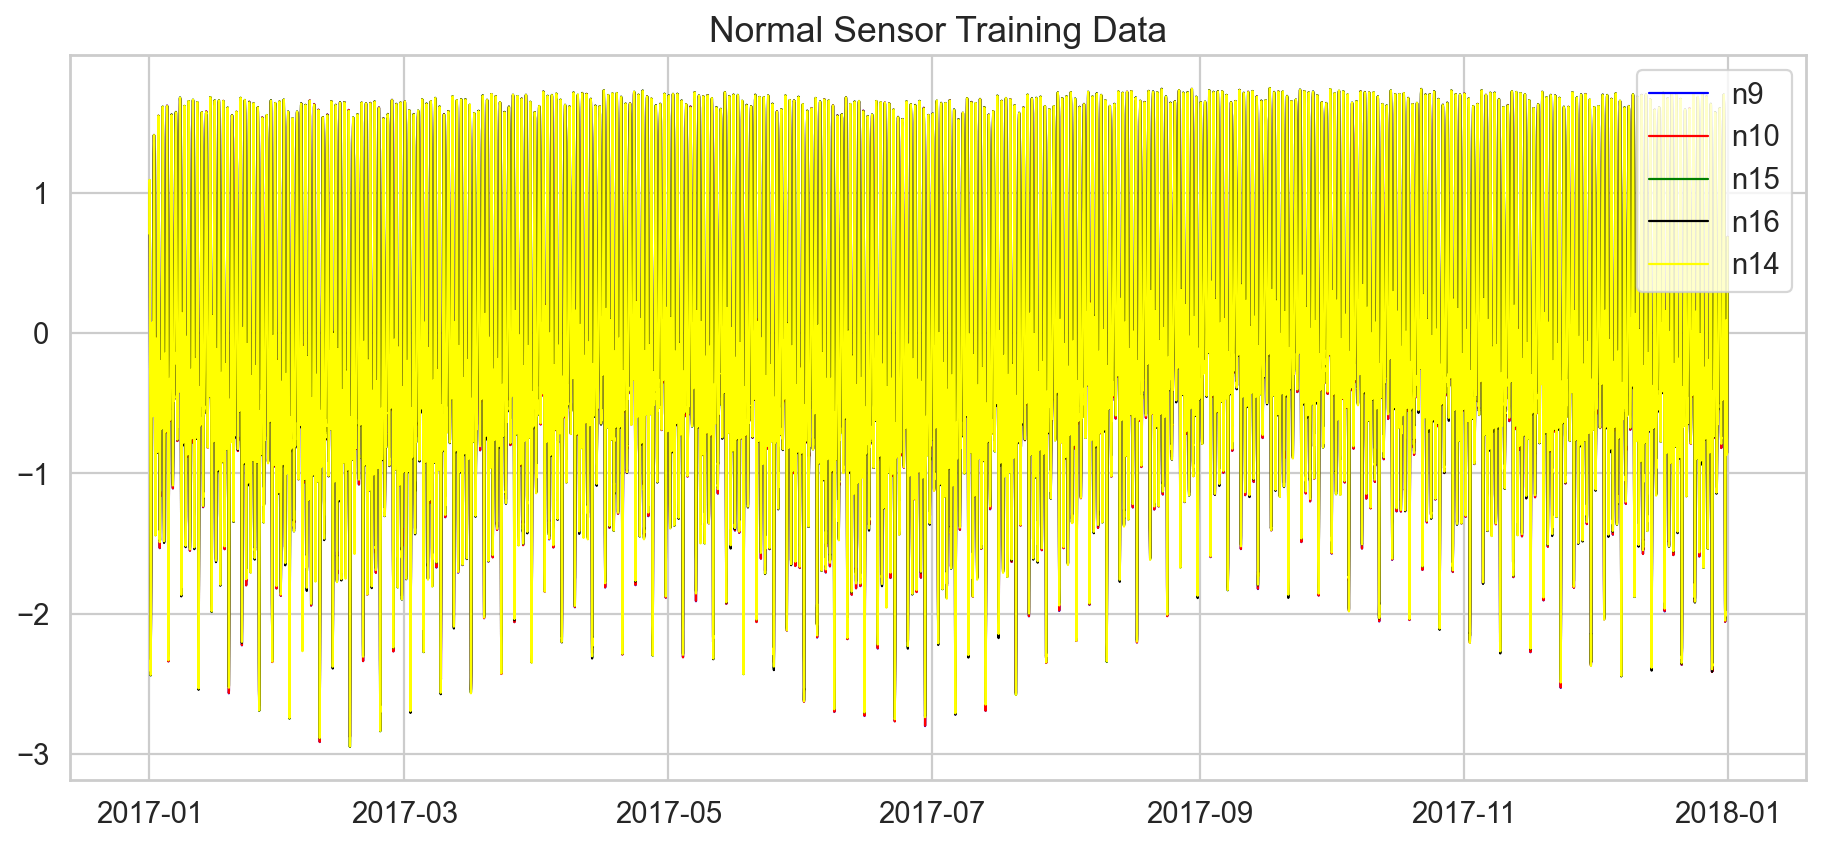

In [16]:
fig, ax = plt.subplots(figsize=(14,6), dpi = 80) #for leak 14 - sensors nearby are 9, 10, 15, 16
ax.plot(train['Node_9'], label = 'n9', color='blue', linewidth=1)
ax.plot(train['Node_10'], label = 'n10', color='red', linewidth=1)
ax.plot(train['Node_15'], label = 'n15', color='green', linewidth=1)
ax.plot(train['Node_16'], label = 'n16', color='black', linewidth=1)
ax.plot(train['Node_14'], label = 'n14', color='yellow', linewidth=1)
plt.legend(loc='upper right')
ax.set_title('Normal Sensor Training Data',fontsize=16)
plt.show();

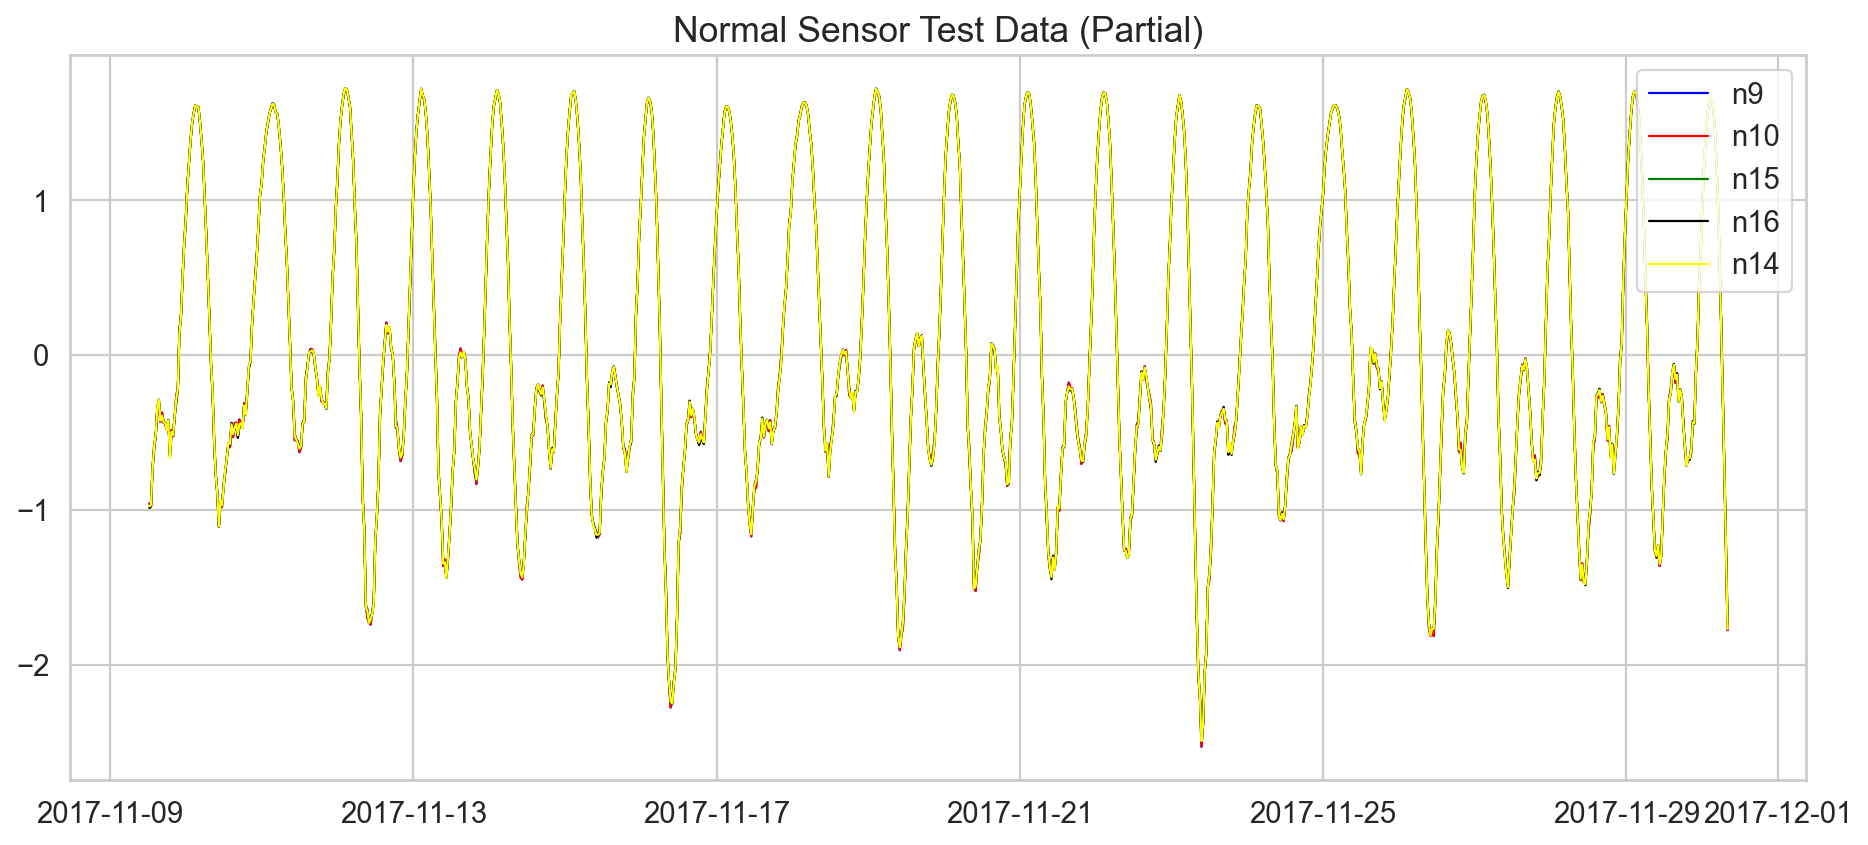

In [17]:
# show only 10000 data points around leak time (otherwise difficult to compare)
fig, ax = plt.subplots(figsize=(14,6), dpi = 80)
ax.plot(train['Node_9'][15000:16000], label = 'n9', color='blue', linewidth=1)
ax.plot(train['Node_10'][15000:16000], label = 'n10', color='red', linewidth=1)
ax.plot(train['Node_15'][15000:16000], label = 'n15', color='green', linewidth=1)
ax.plot(train['Node_16'][15000:16000], label = 'n16', color='black', linewidth=1)
ax.plot(train['Node_14'][15000:16000], label = 'n14', color='yellow', linewidth=1)
plt.legend(loc='upper right')
ax.set_title('Normal Sensor Test Data (Partial)',fontsize=16)
plt.show();

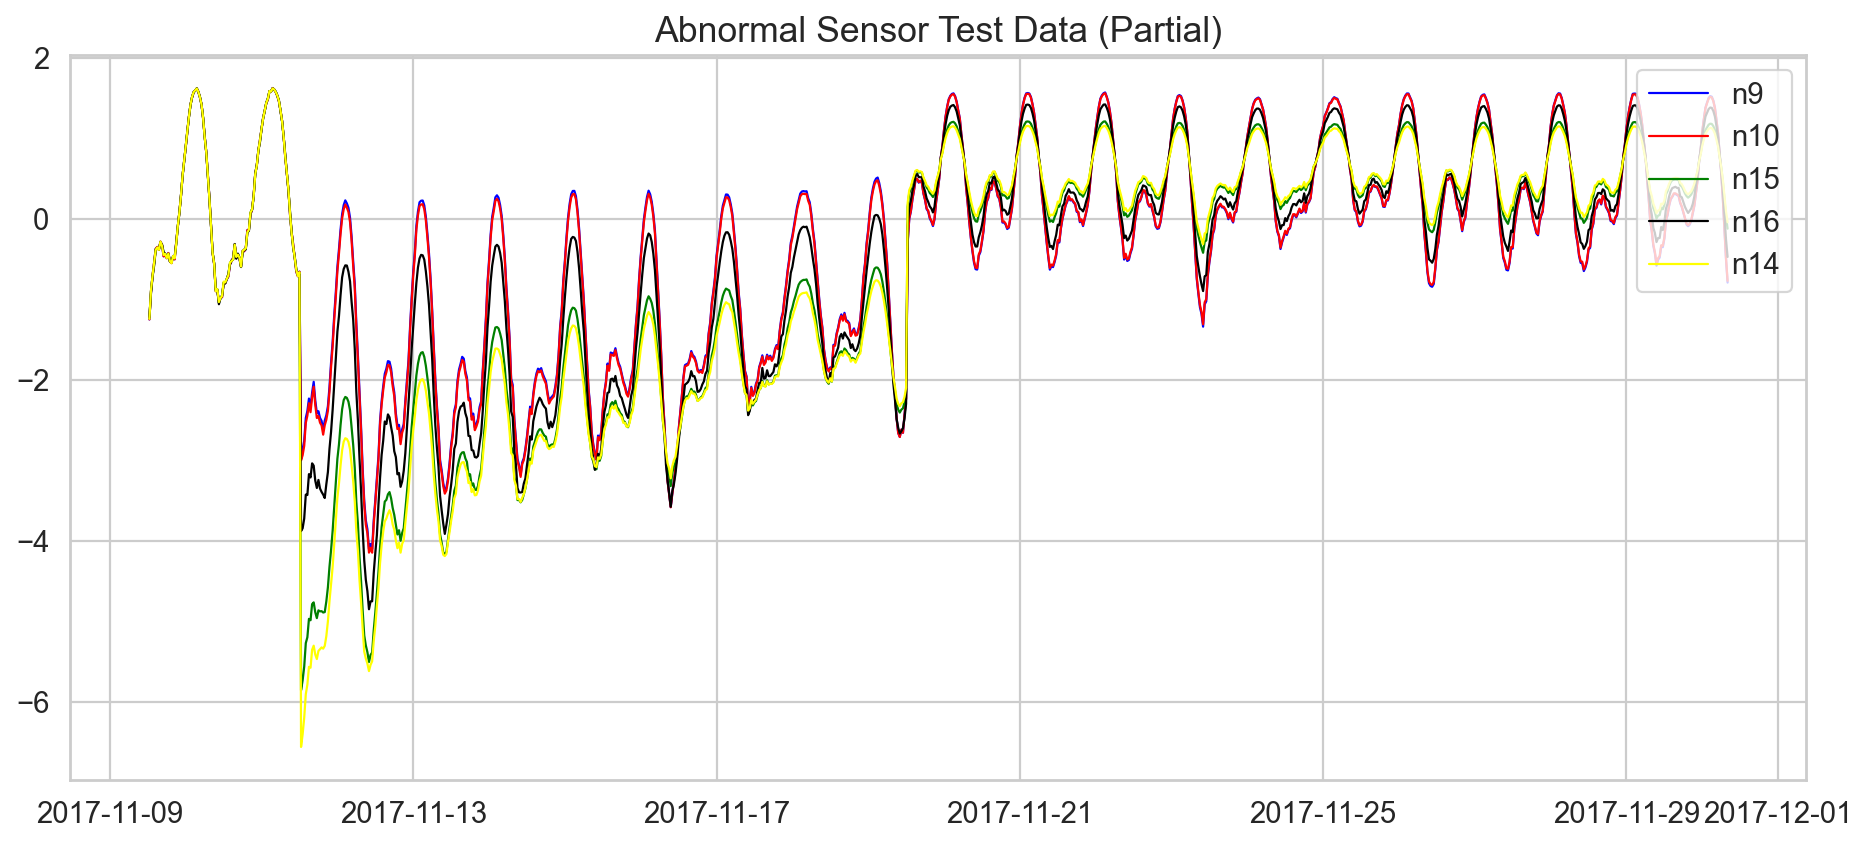

In [ ]:
# show the same for the test data
fig, ax = plt.subplots(figsize=(14,6), dpi = 80)
ax.plot(test['Node_9'][15000:16000], label = 'n9', color='blue', linewidth=1)
ax.plot(test['Node_10'][15000:16000], label = 'n10', color='red', linewidth=1)
ax.plot(test['Node_15'][15000:16000], label = 'n15', color='green', linewidth=1)
ax.plot(test['Node_16'][15000:16000], label = 'n16', color='black', linewidth=1)
ax.plot(test['Node_14'][15000:16000], label = 'n14', color='yellow', linewidth=1)
plt.legend(loc='upper right')
ax.set_title('Abnormal Sensor Test Data (Partial)',fontsize=16)
plt.show();

### Breaking the data into sequences
This is necessary to suit the input format expected by the LSTM, as well as to have windowed sequences (i.e. with lookback)

In [ ]:
#list out the columns in the training data; we'll need these later for preprocessing
train.columns

Index(['Index', 'Node_21', 'Node_20', 'Node_8', 'Node_22', 'Node_23', 'Node_9',
       'Node_27', 'Node_32', 'Node_26', 'Node_18', 'Node_30', 'Node_24',
       'Node_25', 'Node_31', 'Node_19', 'Node_2', 'Node_14', 'Node_28',
       'Node_29', 'Node_15', 'Node_3', 'Node_17', 'Node_16', 'Node_4',
       'Node_12', 'Node_13', 'Node_5', 'Node_7', 'Node_11', 'Node_10',
       'Node_6', 'Link_1'],
      dtype='object')

This code here is what was was used to create the sequences; however, the next cell contains the same code in a better, miniaturised form. I encourage you to use the latter, but left this here as it's more explainable/easier to understand.

In [ ]:
# multivariate data preparation
from numpy import array
from numpy import hstack

# split a multivariate sequence into samples
def split_sequences(sequences, n_steps):
	X = list()
	for i in range(len(sequences)):
		# find the end of this pattern
		end_ix = i + n_steps
		# check if we are beyond the dataset
		if end_ix > len(sequences):
			break
		# gather pattern
		seq_x = sequences[i:end_ix]
		X.append(seq_x)
	return array(X)

# define train sequence
in_seq2 = train['Node_2'].values
in_seq3 = train['Node_3'].values
in_seq4 = train['Node_4'].values
in_seq5 = train['Node_5'].values
in_seq_6 = train['Node_6'].values
in_seq_7 = train['Node_7'].values
in_seq_8 = train['Node_8'].values
in_seq_9 = train['Node_9'].values
in_seq_10 = train['Node_10'].values
in_seq_11 = train['Node_11'].values
in_seq_12 = train['Node_12'].values
in_seq_13 = train['Node_13'].values
in_seq_14 = train['Node_14'].values
in_seq_15 = train['Node_15'].values
in_seq_16 = train['Node_16'].values
in_seq_17 = train['Node_17'].values
in_seq_18 = train['Node_18'].values
in_seq_19 = train['Node_19'].values
in_seq_20 = train['Node_20'].values
in_seq_21 = train['Node_21'].values
in_seq_22 = train['Node_22'].values
in_seq_23 = train['Node_23'].values
in_seq_24 = train['Node_24'].values
in_seq_25 = train['Node_25'].values
in_seq_26 = train['Node_26'].values
in_seq_27 = train['Node_27'].values
in_seq_28 = train['Node_28'].values
in_seq_29 = train['Node_29'].values
in_seq_30 = train['Node_30'].values
in_seq_31 = train['Node_31'].values
in_seq_32 = train['Node_32'].values
in_seq_33 = train['Link_1'].values



# convert to [rows, columns] structure
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
in_seq3 = in_seq3.reshape((len(in_seq3), 1))
in_seq4 = in_seq4.reshape((len(in_seq4), 1))
in_seq5 = in_seq5.reshape((len(in_seq5), 1))
in_seq_6 = in_seq_6.reshape((len(in_seq_6), 1))
in_seq_7 = in_seq_7.reshape((len(in_seq_7), 1))
in_seq_8 = in_seq_8.reshape((len(in_seq_8), 1))
in_seq_9 = in_seq_9.reshape((len(in_seq_9), 1))
in_seq_10 = in_seq_10.reshape((len(in_seq_10), 1))
in_seq_11 = in_seq_11.reshape((len(in_seq_11), 1))
in_seq_12 = in_seq_12.reshape((len(in_seq_12), 1))
in_seq_13 = in_seq_13.reshape((len(in_seq_13), 1))
in_seq_14 = in_seq_14.reshape((len(in_seq_14), 1))
in_seq_15 = in_seq_15.reshape((len(in_seq_15), 1))
in_seq_16 = in_seq_16.reshape((len(in_seq_16), 1))
in_seq_17 = in_seq_17.reshape((len(in_seq_17), 1))
in_seq_18 = in_seq_18.reshape((len(in_seq_18), 1))
in_seq_19 = in_seq_19.reshape((len(in_seq_19), 1))
in_seq_20 = in_seq_20.reshape((len(in_seq_20), 1))
in_seq_21 = in_seq_21.reshape((len(in_seq_21), 1))
in_seq_22 = in_seq_22.reshape((len(in_seq_22), 1))
in_seq_23 = in_seq_23.reshape((len(in_seq_23), 1))
in_seq_24 = in_seq_24.reshape((len(in_seq_24), 1))
in_seq_25 = in_seq_25.reshape((len(in_seq_25), 1))
in_seq_26 = in_seq_26.reshape((len(in_seq_26), 1))
in_seq_27 = in_seq_27.reshape((len(in_seq_27), 1))
in_seq_28 = in_seq_28.reshape((len(in_seq_28), 1))
in_seq_29 = in_seq_29.reshape((len(in_seq_29), 1))
in_seq_30 = in_seq_30.reshape((len(in_seq_30), 1))
in_seq_31 = in_seq_31.reshape((len(in_seq_31), 1))
in_seq_32 = in_seq_32.reshape((len(in_seq_32), 1))
in_seq_33 = in_seq_33.reshape((len(in_seq_33), 1))


# define test sequence
# ts_seq1 = test['Node_1'].values
ts_seq2 = test['Node_2'].values
ts_seq3 = test['Node_3'].values
ts_seq4 = test['Node_4'].values
ts_seq5 = test['Node_5'].values
ts_seq6 = test['Node_6'].values
ts_seq7 = test['Node_7'].values
ts_seq8 = test['Node_8'].values
ts_seq9 = test['Node_9'].values
ts_seq10 = test['Node_10'].values
ts_seq11 = test['Node_11'].values
ts_seq12 = test['Node_12'].values
ts_seq13 = test['Node_13'].values
ts_seq14 = test['Node_14'].values
ts_seq15 = test['Node_15'].values
ts_seq16 = test['Node_16'].values
ts_seq17 = test['Node_17'].values
ts_seq18 = test['Node_18'].values
ts_seq19 = test['Node_19'].values
ts_seq20 = test['Node_20'].values
ts_seq21 = test['Node_21'].values
ts_seq22 = test['Node_22'].values
ts_seq23 = test['Node_23'].values
ts_seq24 = test['Node_24'].values
ts_seq25 = test['Node_25'].values
ts_seq26 = test['Node_26'].values
ts_seq27 = test['Node_27'].values
ts_seq28 = test['Node_28'].values
ts_seq29 = test['Node_29'].values
ts_seq30 = test['Node_30'].values
ts_seq31 = test['Node_31'].values
ts_seq32 = test['Node_32'].values
ts_seq33 = test['Link_1'].values



# convert to [rows, columns] structure
ts_seq2 = ts_seq2.reshape((len(ts_seq2), 1))
ts_seq3 = ts_seq3.reshape((len(ts_seq3), 1))
ts_seq4 = ts_seq4.reshape((len(ts_seq4), 1))
ts_seq5 = ts_seq5.reshape((len(ts_seq5), 1))
ts_seq6 = ts_seq6.reshape((len(ts_seq6), 1))
ts_seq7 = ts_seq7.reshape((len(ts_seq7), 1))
ts_seq8 = ts_seq8.reshape((len(ts_seq8), 1))
ts_seq9 = ts_seq9.reshape((len(ts_seq9), 1))
ts_seq10 = ts_seq10.reshape((len(ts_seq10), 1))
ts_seq11 = ts_seq11.reshape((len(ts_seq11), 1))
ts_seq12 = ts_seq12.reshape((len(ts_seq12), 1))
ts_seq13 = ts_seq13.reshape((len(ts_seq13), 1))
ts_seq14 = ts_seq14.reshape((len(ts_seq14), 1))
ts_seq15 = ts_seq15.reshape((len(ts_seq15), 1))
ts_seq16 = ts_seq16.reshape((len(ts_seq16), 1))
ts_seq17 = ts_seq17.reshape((len(ts_seq17), 1))
ts_seq18 = ts_seq18.reshape((len(ts_seq18), 1))
ts_seq19 = ts_seq19.reshape((len(ts_seq19), 1))
ts_seq20 = ts_seq20.reshape((len(ts_seq20), 1))
ts_seq21 = ts_seq21.reshape((len(ts_seq21), 1))
ts_seq22 = ts_seq22.reshape((len(ts_seq22), 1))
ts_seq23 = ts_seq23.reshape((len(ts_seq23), 1))
ts_seq24 = ts_seq24.reshape((len(ts_seq24), 1))
ts_seq25 = ts_seq25.reshape((len(ts_seq25), 1))
ts_seq26 = ts_seq26.reshape((len(ts_seq26), 1))
ts_seq27 = ts_seq27.reshape((len(ts_seq27), 1))
ts_seq28 = ts_seq28.reshape((len(ts_seq28), 1))
ts_seq29 = ts_seq29.reshape((len(ts_seq29), 1))
ts_seq30 = ts_seq30.reshape((len(ts_seq30), 1))
ts_seq31 = ts_seq31.reshape((len(ts_seq31), 1))
ts_seq32 = ts_seq32.reshape((len(ts_seq32), 1))
ts_seq33 = ts_seq33.reshape((len(ts_seq33), 1))


# horizontally stack columns (one for training and one for testing)
train_dataset = hstack((in_seq2, in_seq3, in_seq4, in_seq5, in_seq_6, in_seq_7, in_seq_8, in_seq_9, in_seq_10, in_seq_11, in_seq_12, in_seq_13, in_seq_14, in_seq_15, in_seq_16, in_seq_17, in_seq_18, in_seq_19, in_seq_20, in_seq_21, in_seq_22, in_seq_23, in_seq_24, in_seq_25, in_seq_26, in_seq_27, in_seq_28, in_seq_29, in_seq_30, in_seq_31, in_seq_32, in_seq_33))
test_dataset = hstack((ts_seq2, ts_seq3, ts_seq4, ts_seq5, ts_seq6, ts_seq7, ts_seq8, ts_seq9, ts_seq10, ts_seq11, ts_seq12, ts_seq13, ts_seq14, ts_seq15, ts_seq16, ts_seq17, ts_seq18, ts_seq19, ts_seq20, ts_seq21, ts_seq22, ts_seq23, ts_seq24, ts_seq25, ts_seq26, ts_seq27, ts_seq28, ts_seq29, ts_seq30, ts_seq31, ts_seq32, ts_seq33))


# choose a number of time steps (lookback)
n_steps = 24 #half a day in this example, but the final code used 48 (1 day)
# convert into input/output
X_seq_train= split_sequences(train_dataset, n_steps)
X_seq_test= split_sequences(test_dataset, n_steps)
print(X_seq_train.shape)
print(X_seq_test.shape)

(17496, 24, 32)
(17496, 24, 32)


NOTE: Code below only does test sequences, but should be easy enough to modify to do train as well

In [ ]:
# for all columns
columns = ['Node_21', 'Node_20', 'Node_8', 'Node_22', 'Node_23', 'Node_9',
        'Node_27', 'Node_32', 'Node_26', 'Node_18', 'Node_30', 'Node_24',
        'Node_25', 'Node_31', 'Node_19', 'Node_2', 'Node_14', 'Node_28',
        'Node_29', 'Node_15', 'Node_3', 'Node_17', 'Node_16', 'Node_4',
        'Node_12', 'Node_13', 'Node_5', 'Node_7', 'Node_11', 'Node_10',
        'Node_6', 'Link_1']

# split a multivariate sequence into samples
def split_sequences(sequences, n_steps):
    X = list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the dataset
        if end_ix > len(sequences):
            break
        # gather pattern
        seq_x = sequences[i:end_ix]
        X.append(seq_x)
    return np.array(X)

# define test sequences
test_sequences = []

# get the values for each column and reshape to 2D
for column in columns:
    test_sequences.append(test[column].values.reshape((len(test[column]), 1)))

# horizontally stack columns
test_dataset = np.hstack(test_sequences)

# choose a number of time steps
n_steps = 48  # one day window

# convert into output shape
X_seq_test = split_sequences(test_dataset, n_steps)
print(X_seq_test.shape)

The training set is split into train (85%) and validation (15%). The validation set is used to "test the model while training".

In [21]:
X_s_train, X_s_val = train_test_split(X_seq_train, test_size = 0.15, random_state=RANDOM_SEED)
print("Training data shape:", X_s_train.shape)
print("Validation data shape:", X_s_val.shape)
print("Test data shape:", X_seq_test.shape)

Training data shape: (14871, 24, 32)
Validation data shape: (2625, 24, 32)
Test data shape: (17496, 24, 32)


In [ ]:
# convert to tensors (to enable GPU processing)
x_s_train_tensor = torch.as_tensor(X_s_train.astype(np.float32))
x_s_val_tensor = torch.as_tensor(X_s_val.astype(np.float32))
x_s_test_tensor = torch.as_tensor(X_seq_test.astype(np.float32))
x_s_train_tensor.shape

torch.Size([14871, 24, 32])

## Modeling(Autoencoder MV LSTM)

Here we define the model and it's training loop (next cell below)

In [23]:
class MVLSTMAutoEncoder(nn.Module):
    def __init__(self, seq_len, embedding_dim, feature_size):
        super(MVLSTMAutoEncoder, self).__init__()
        #input parameters
        self.seq_len = seq_len #window length
        self.feature_size = feature_size #number of columns
        self.hidden_1 = embedding_dim * 2 #starting hidden size
        self.hidden_2 = embedding_dim #ending hidden size (embedding dimension)

        self.encode1 = nn.LSTM(input_size=self.feature_size, hidden_size=self.hidden_1, num_layers=1, bidirectional=False, batch_first=True)
        self.encode2 = nn.LSTM(input_size=self.hidden_1, hidden_size=self.hidden_2, num_layers=1, bidirectional=False, batch_first=True)

        self.decode1 = nn.LSTM(input_size=self.hidden_2, hidden_size=self.hidden_2, num_layers=1, bidirectional=False, batch_first=True)
        self.decode2 = nn.LSTM(input_size=self.hidden_2, hidden_size=self.hidden_1, num_layers=1, bidirectional=False, batch_first=True)

        self.dense = nn.Linear(self.hidden_1, self.feature_size)

    def forward(self, x):
        x, _ = self.encode1(x)
        x, _ = self.encode2(x)
        x, _ = self.decode1(x)
        x, _ = self.decode2(x)
        x = self.dense(x)
        return x

In [24]:
def train_model(training_dataset, val_dataset, n_epochs, embedding_dim):
    feature_size = training_dataset.shape[-1]
    window_size = training_dataset.shape[1]
    model = MVLSTMAutoEncoder(seq_len=window_size, embedding_dim=embedding_dim, feature_size=feature_size)
    model = model.to(args.device)
    
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)

    criterion = nn.L1Loss(reduction='sum').to(args.device)

    history = dict(train=[], val=[])

    for epoch in range(1 , n_epochs + 1):
        model = model.train()
        ts = time.time()
        train_losses = []

        for seq_true in training_dataset:
            optimizer.zero_grad()

            seq_true = seq_true.to(args.device)
            seq_pred = model(seq_true)
    
            loss = criterion(seq_pred, seq_true)
            
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        val_losses = []
        model = model.eval()
        with torch.no_grad():
            for seq_true in val_dataset:

                seq_true = seq_true.to(args.device)
                seq_pred = model(seq_true)

                loss = criterion(seq_pred, seq_true)

                val_losses.append(loss.item())
        te = time.time()
        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history['train'].append(train_loss)
        history['val'].append(val_loss)
        
        print(f"Epoch: {epoch}  train loss: {train_loss}  val loss: {val_loss}  time: {te-ts} ")

    return model.eval(), history    

## Experiment

In [ ]:
#Check for Metal on Mac - if on Windows, check for CUDA instead!
if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

tensor([1.], device='mps:0')


### Training the model
The only variables that matter to you here are the embedding dimension, learning rate (lr) and epochs.

The code was made in a way to allow arguments to be passed in by the user during runtime (if executed as a .py file), but feel free to change these to standard variables if that's easier for you to work with.

We run this for just 12 epochs in this example, each epoch taking about 6mins to train.

In [28]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

parser = argparse.ArgumentParser()
args = parser.parse_args('')

args.device = 'mps' if torch.backends.mps.is_available else 'cpu'

# ==== model capacity ==== #
args.n_layers = 1
args.embedding_dim = 32

# ==== optimizer & training  # ====
args.lr = 0.001
args.epoch = 12



# ==== Experiment Variable ==== #
# model, history = train_model(train_dataset, val_dataset, n_epochs, embedding_dim)
model, history = train_model(x_s_train_tensor, x_s_val_tensor, args.epoch, args.embedding_dim)

Epoch: 1  train loss: 24.338037739379782  val loss: 10.38910457447597  time: 369.3684871196747 
Epoch: 2  train loss: 15.407470072921415  val loss: 10.090308785393125  time: 332.8083589076996 
Epoch: 3  train loss: 13.600716893574022  val loss: 19.307201149531775  time: 332.67470383644104 
Epoch: 4  train loss: 12.619352048458724  val loss: 10.759722645350864  time: 330.9923779964447 
Epoch: 5  train loss: 12.100690048998361  val loss: 9.433907673245384  time: 330.6641960144043 
Epoch: 6  train loss: 11.458026388467308  val loss: 10.445944225674584  time: 330.73786091804504 
Epoch: 7  train loss: 11.296572993128889  val loss: 9.497710692814419  time: 329.99180698394775 
Epoch: 8  train loss: 10.981433187349683  val loss: 9.507901579720633  time: 332.0864291191101 
Epoch: 9  train loss: 10.78813126104664  val loss: 9.607339255196708  time: 327.97162771224976 
Epoch: 10  train loss: 10.607353716112724  val loss: 9.482843831016904  time: 327.8964982032776 
Epoch: 11  train loss: 10.426512

One of the outputs of the training loop is a history dictionary, with two lists inside it - train and val.

We can plot those to see how the model improves with each epoch.

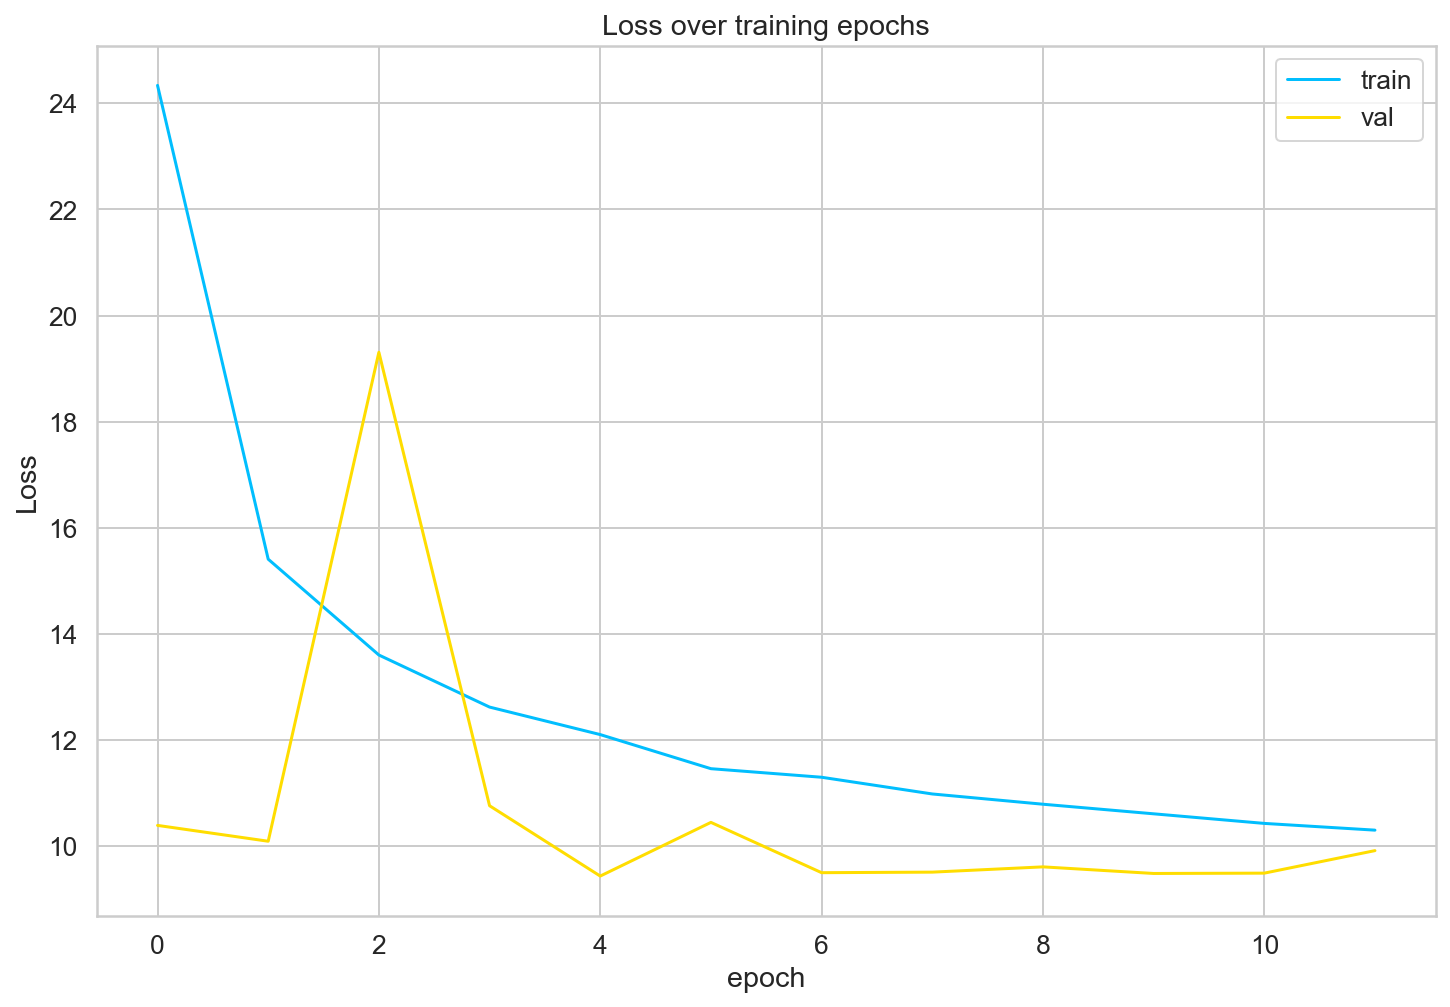

In [29]:
plt.plot(history['train'])
plt.plot(history['val'])
plt.ylabel('Loss')
plt.xlabel('epoch')
plt.title('Loss over training epochs')
plt.legend(['train','val'])
plt.show();

Always a good idea to save out the model after training, since training loops can sometimes take days, depending on the model size & amount of data.

In [ ]:
#save the model
MODEL_PATH = 'all_nodes_normed_12_epoch_model.pth'
torch.save(model, MODEL_PATH)

In [ ]:
# code for loading the model in, incase you need to restart at this point
model = torch.load('all_nodes_normed_12_epoch_model.pth')
model = model.to(args.device)

In [ ]:
# a nice way to see the parameters of the model
print(model)

In [ ]:
#! Don't run before running below cells; breaks "model" variable for some reason
# an alternative (and IMO, better) way to see the model parameters
from torchinfo import summary

summary(model, (2939, 288, 5))

## Test Model

In [ ]:
def predict(model, dataset):
    predictions, losses = [], []
    criterion = nn.L1Loss(reduction='mean').to(args.device)

    with torch.no_grad(): #this ensures that the model doesn't learn anything during this process, as we are only predicting
        model = model.eval()
        for seq_true in dataset:
            seq_true = seq_true.to(args.device)
            seq_pred = model(seq_true)

            loss = criterion(seq_pred, seq_true)

            predictions.append(seq_pred.cpu().numpy().flatten())
            losses.append(loss.item())
    return predictions, losses

<AxesSubplot:ylabel='Count'>

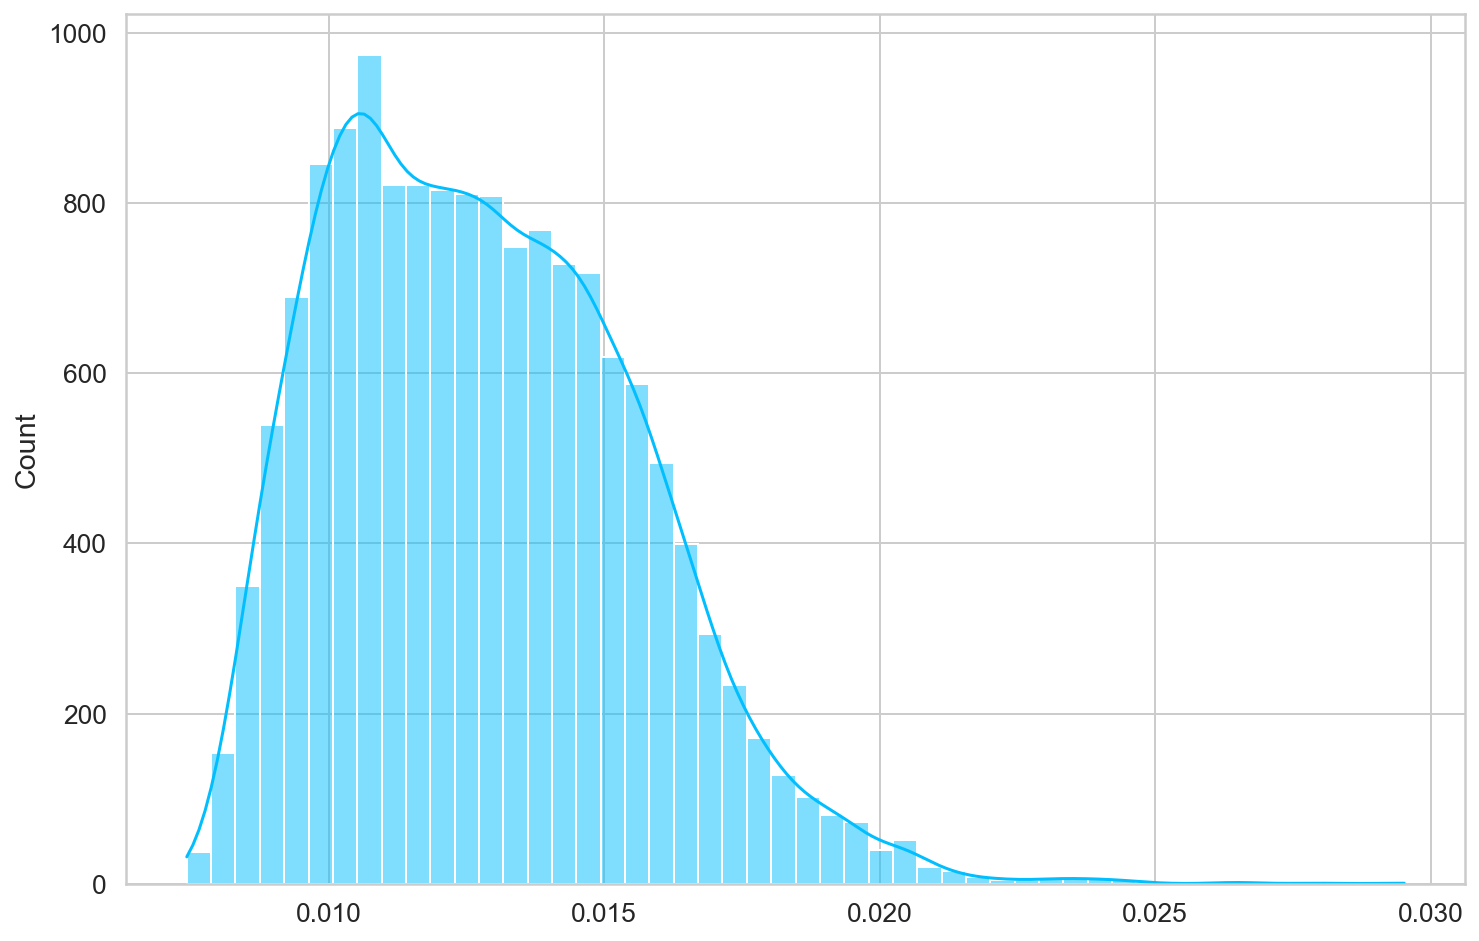

In [ ]:
# check the distribution of the losses in the training set
_, losses = predict(model, x_s_train_tensor)
sns.histplot(losses, bins=50, kde=True)

We see that it's a nice uniform distribution for the training set (above), but an almost "two-headed" distribution for the validation dataset, which means more optimisation of the model still needs to be done (hence your project)

<AxesSubplot:ylabel='Count'>

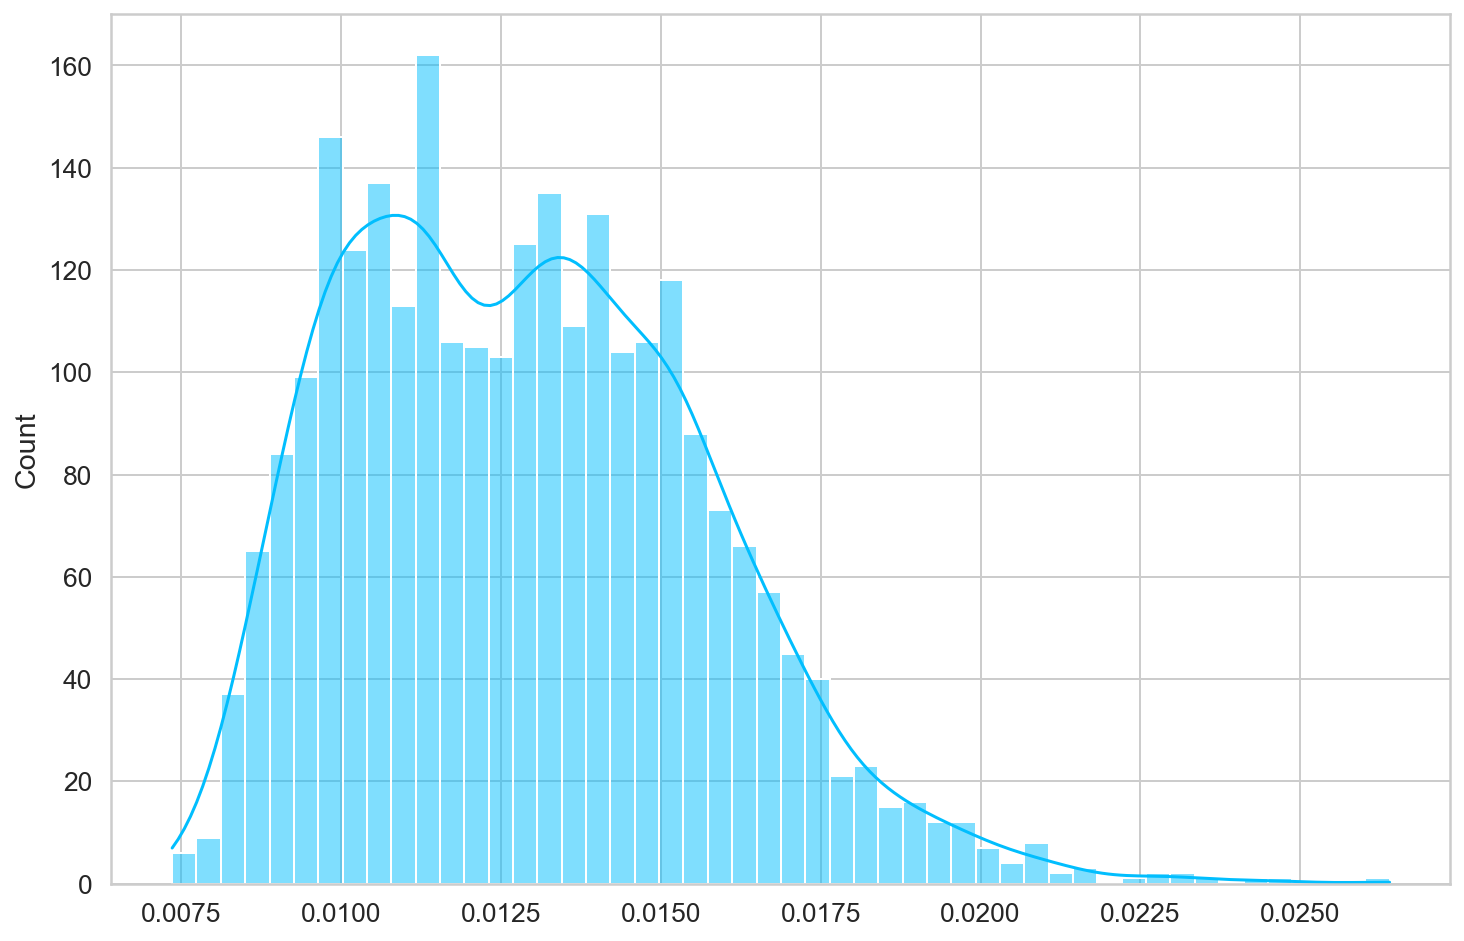

In [33]:
predictions, val_losses = predict(model, x_s_val_tensor)
sns.histplot(val_losses, bins=50, kde= True)

Checking the maximum validation loss allows us to have an estimate of what a good threshold would be for differentiating between normal and anomalous data

In [34]:
#max loss
max(val_losses)

0.026395510882139206

<AxesSubplot:ylabel='Count'>

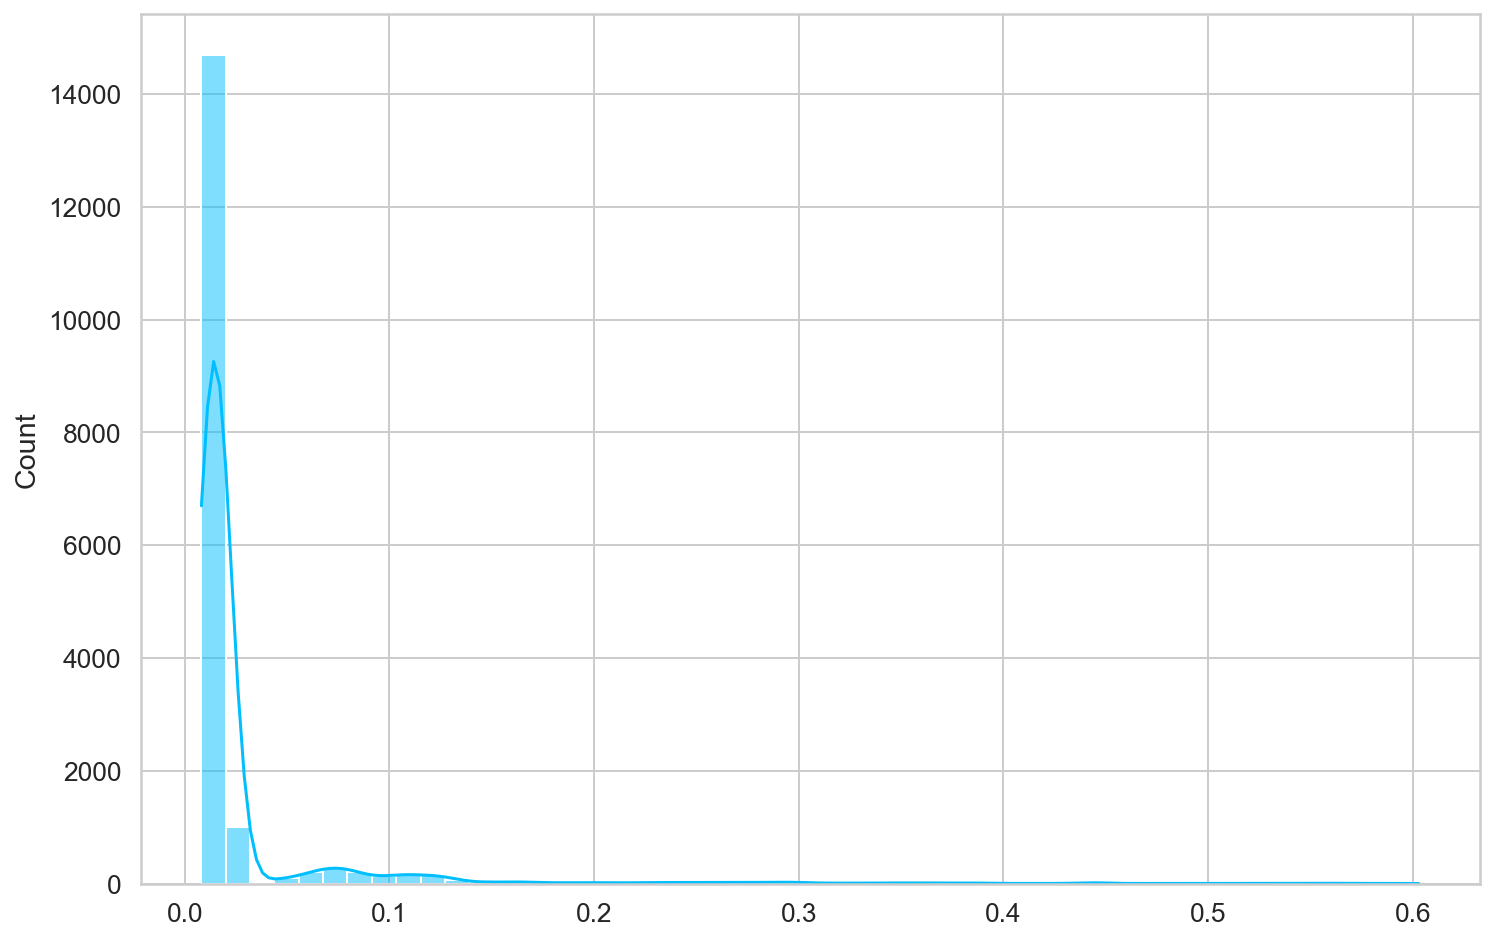

In [35]:
predictions, pred_losses = predict(model, x_s_test_tensor)
sns.histplot(pred_losses,bins=50, kde= True)

As you can see above, in the test set, most of the data is on the left in one distribution (and below the threshold), which some of it forms its own distribution above the threshold

In [36]:
Threshold = 0.028
score = pd.DataFrame(index = test.index)
pred_losses = np.append(np.repeat(np.nan, (len(score.index)-len(pred_losses))), pred_losses)
score['Loss'] = pred_losses
score['Threshold'] = Threshold
score['Anomaly'] = score['Loss'] > score['Threshold']

In [37]:
score = score.dropna()

Logarithmic plot to check the results (of the reconstruction error) against the threshold

<AxesSubplot:xlabel='Timestamp'>

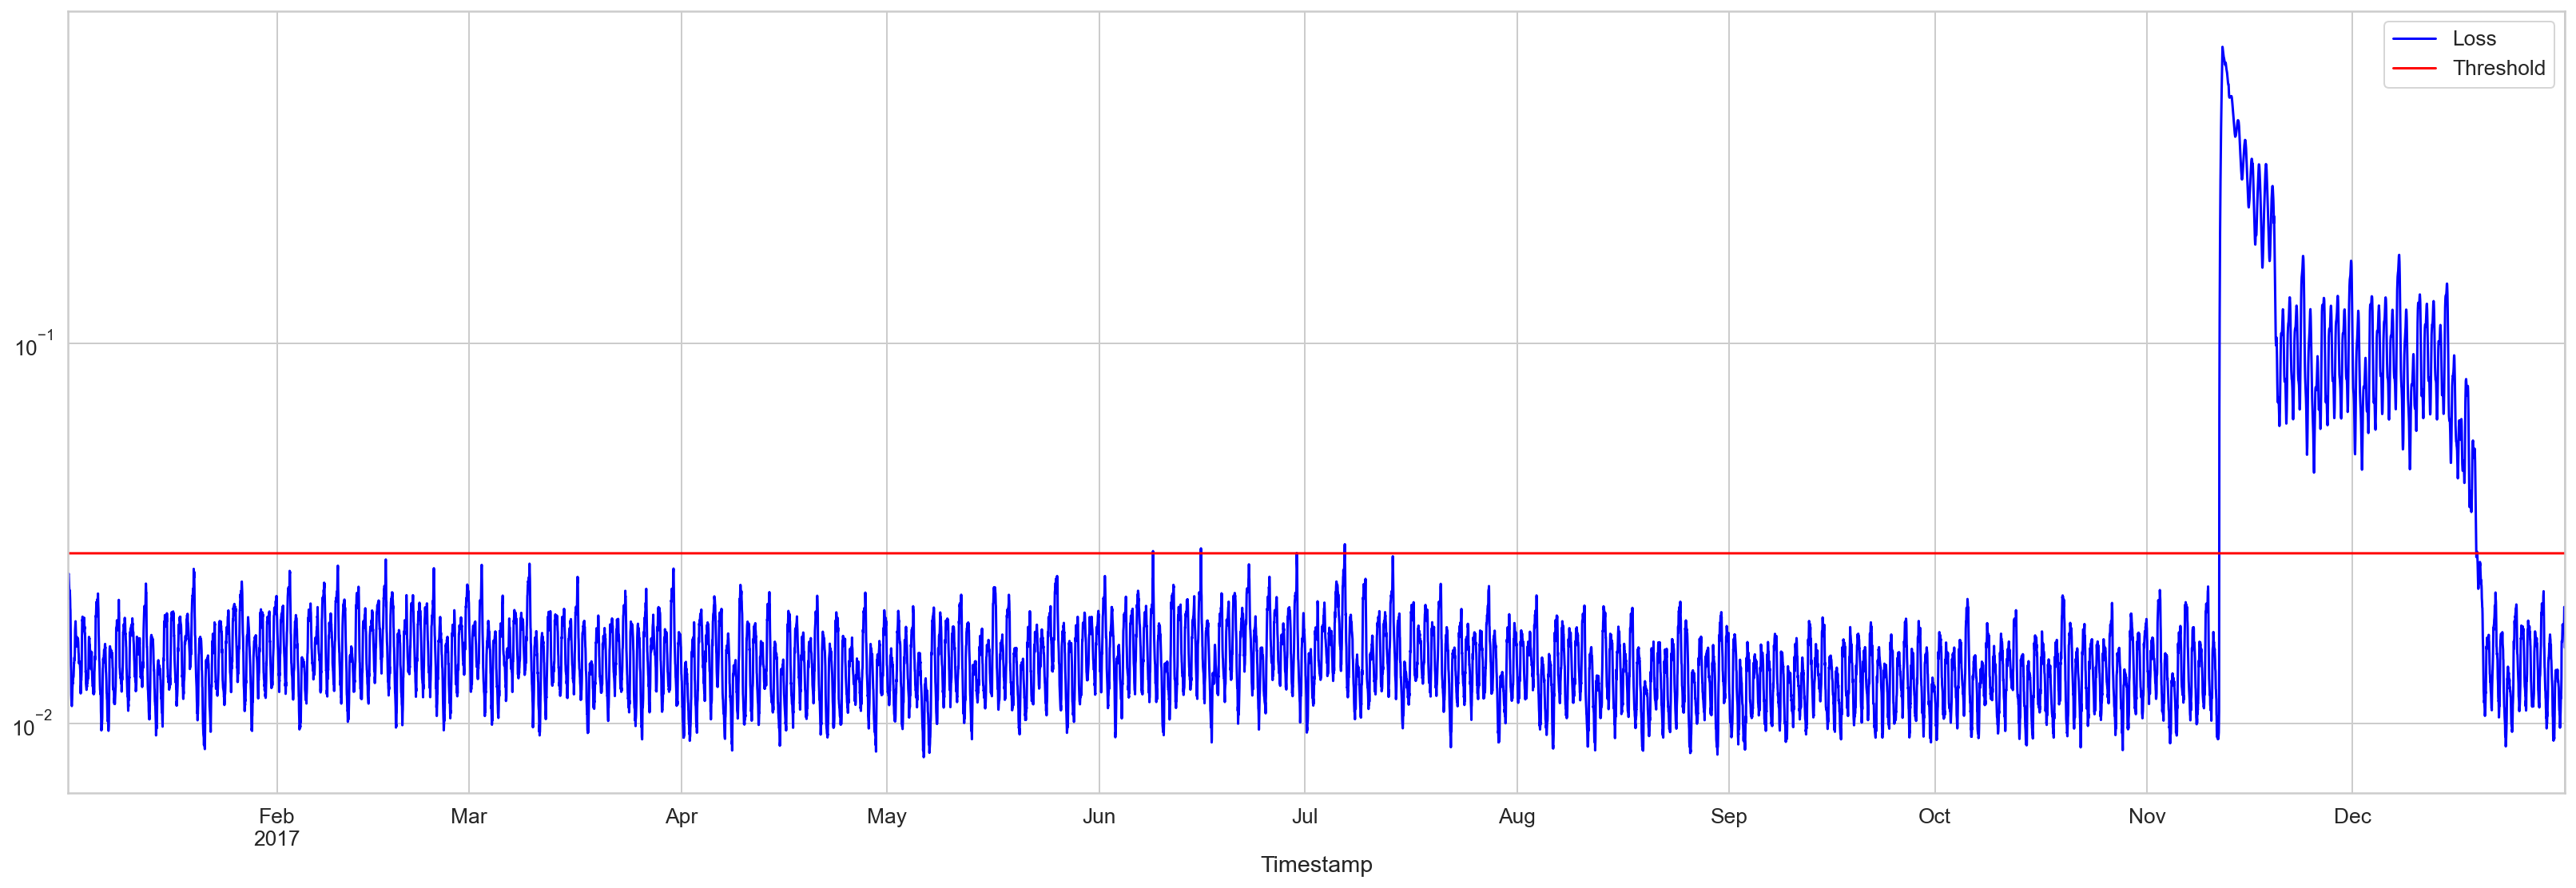

In [38]:
score.plot(logy=True, figsize=(28,9), color=['blue', 'red'])

How the reconstruction error actually looks like, over time

<AxesSubplot:xlabel='Timestamp'>

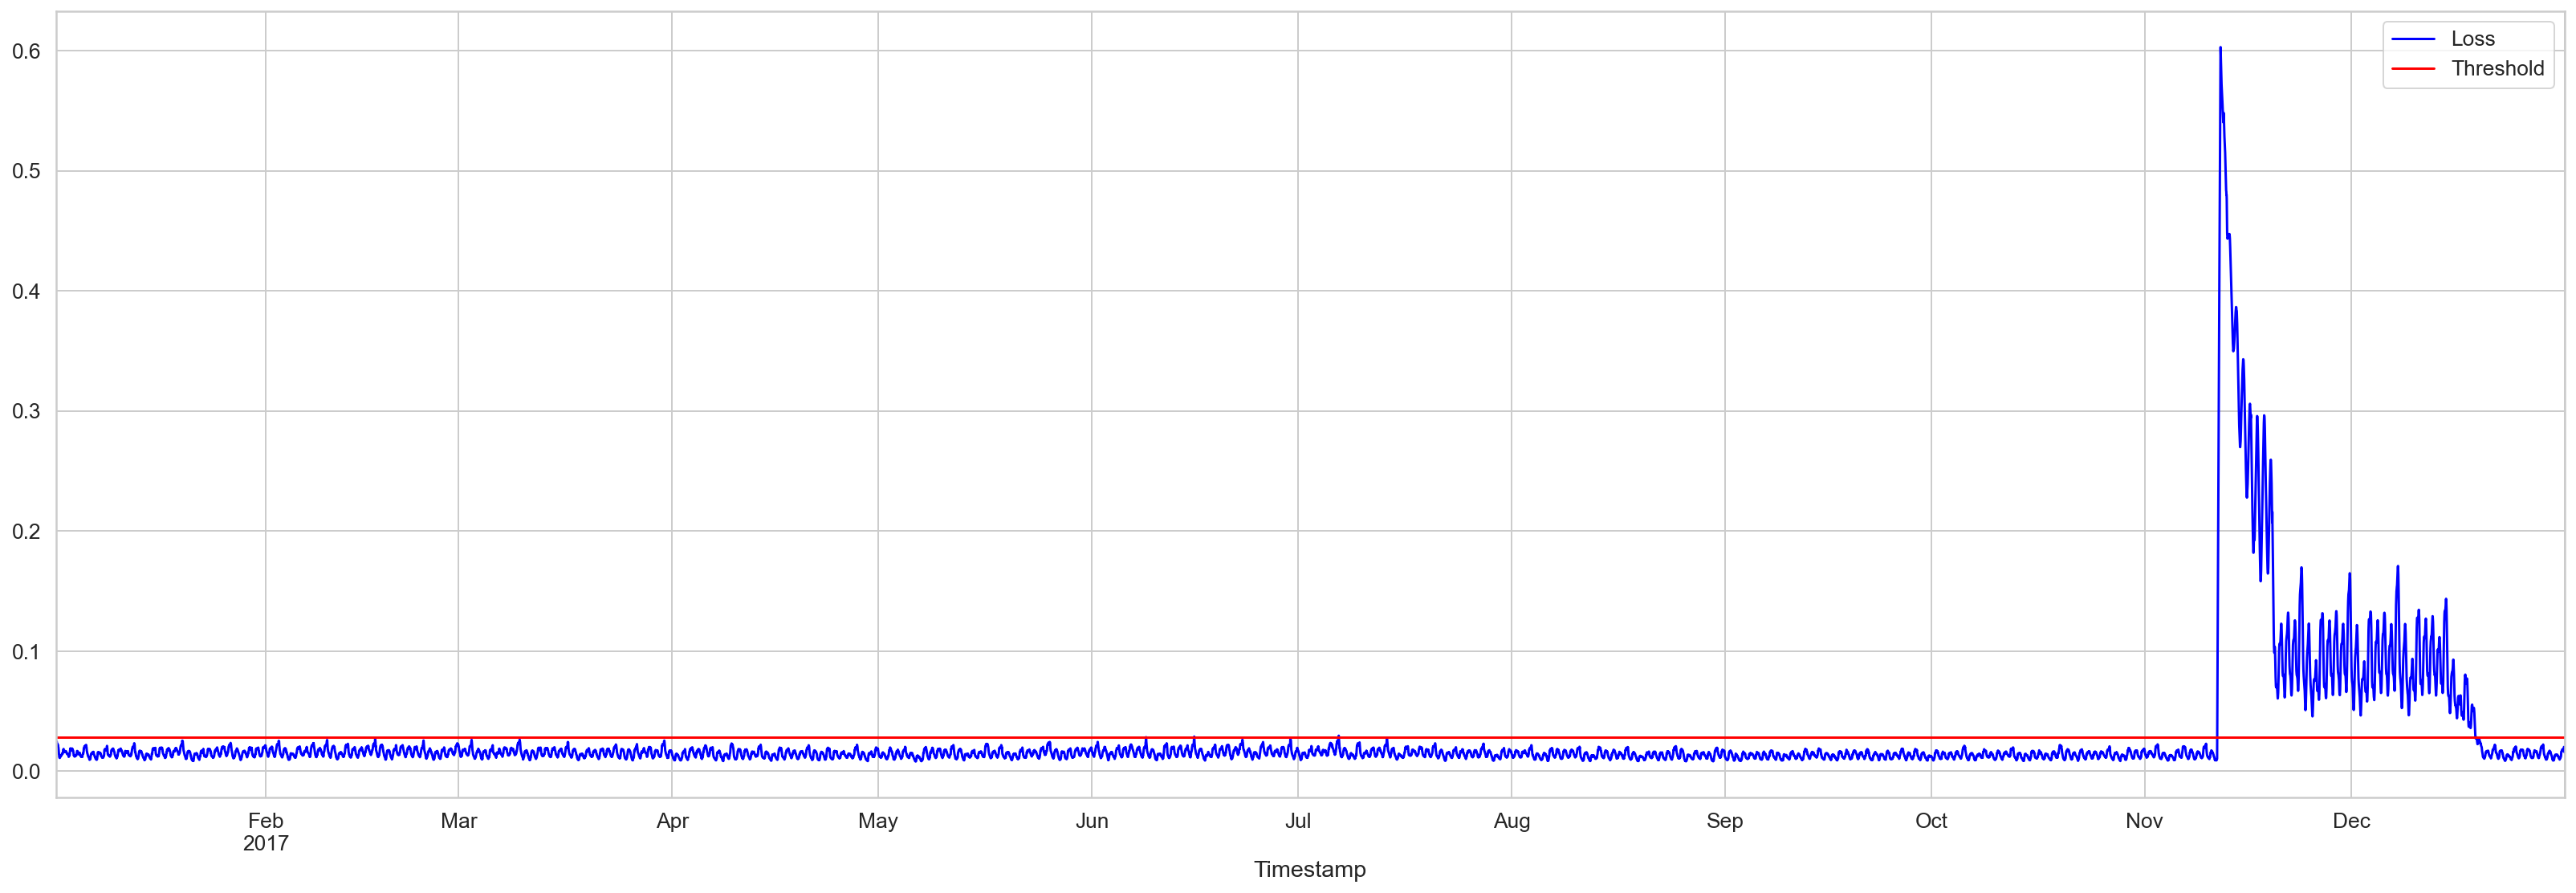

In [39]:
score.plot(figsize=(28,9), color=['blue', 'red'])

Always a good idea to also save out your results, especially if you have large test sets that take a while to compute

In [40]:
score.to_csv('scenario_4_all_normed_predictions.csv')

## Change Point Detection
For more complex results, simple thresholds may sometimes not suffice.

Change point algorithms (like BinSeg, PELT etc) are hence advised.

Note: They do take longer to run though, and require more computational capabilities

In [41]:
import ruptures as rpt

In the PELT algorithm, the parameters we care about are min_size (which is the computation window for changes), and the pen (a penalty value).

The algorithm itself is a bit complex, so for now, just ignore this and focus on using thresholds.

(<Figure size 2016x648 with 1 Axes>, [<AxesSubplot:>])

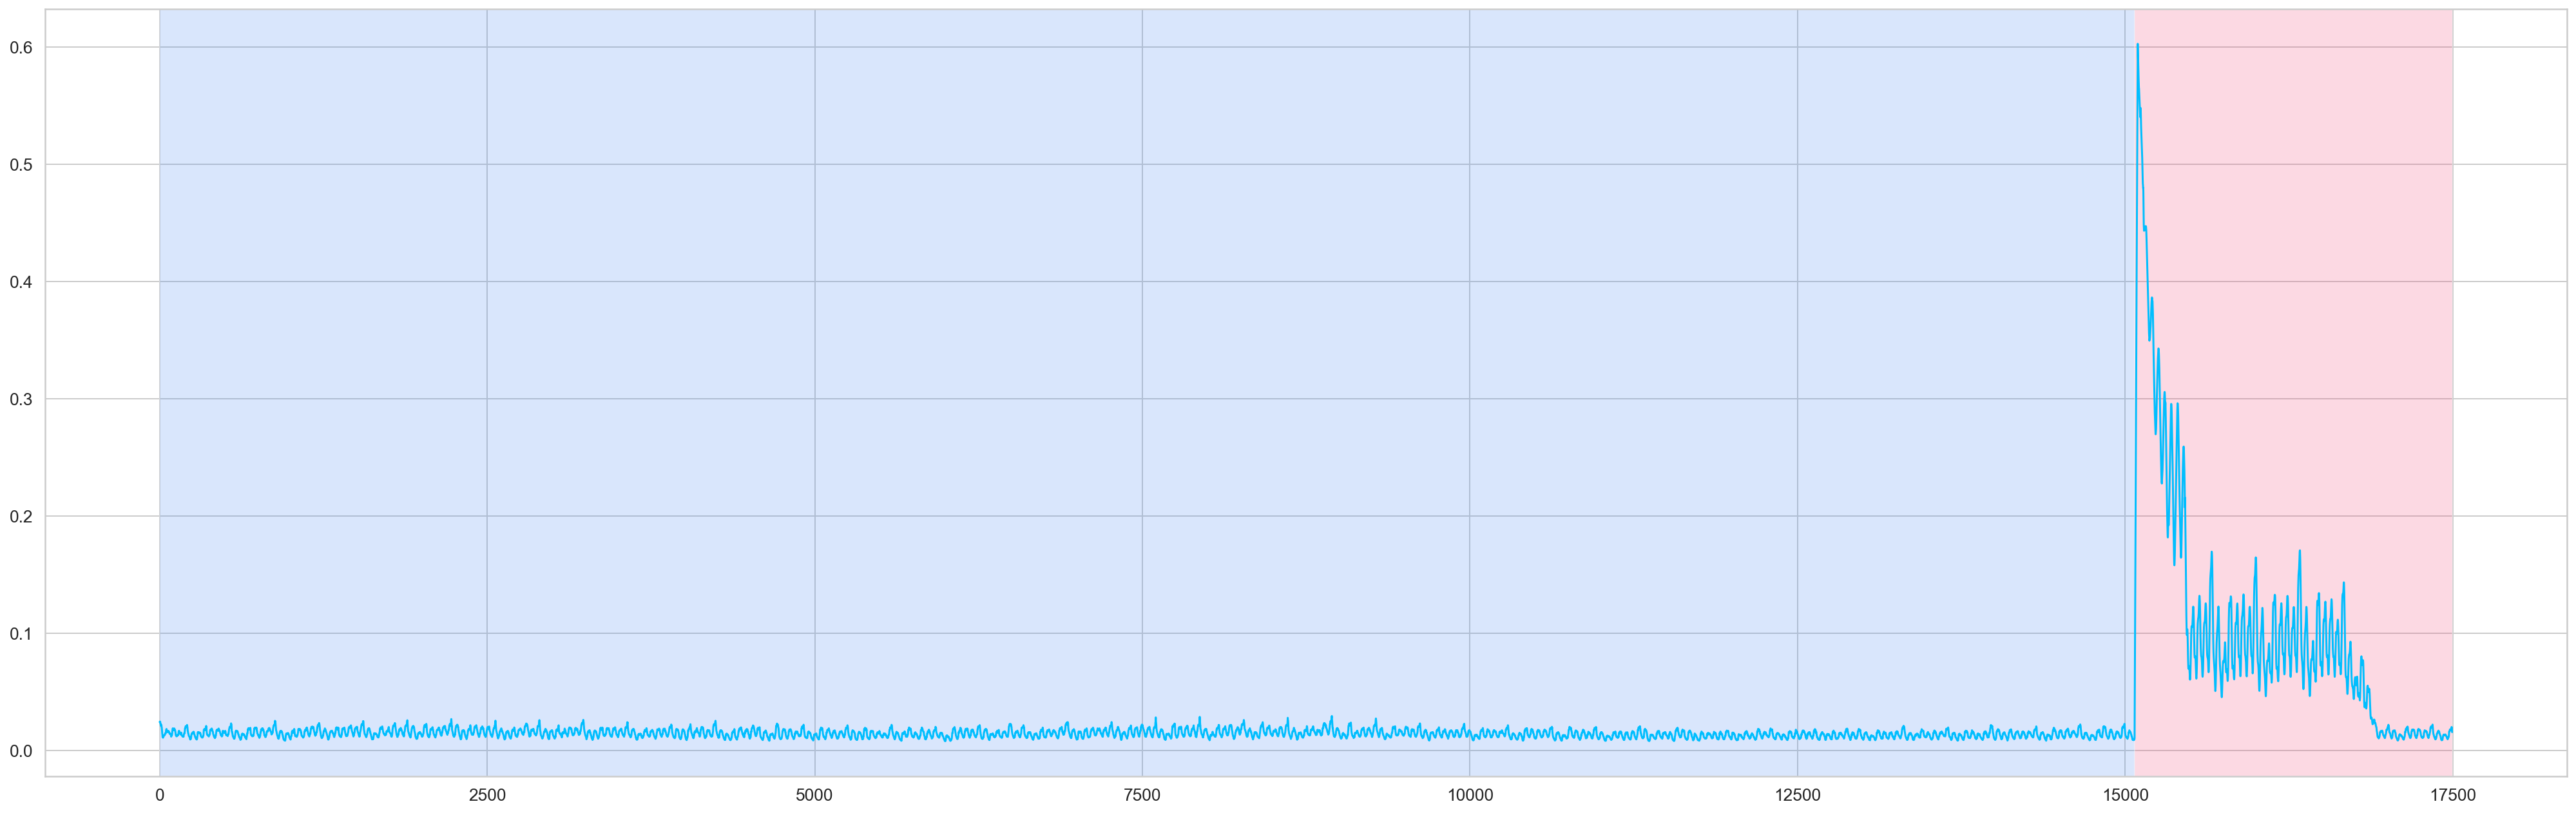

In [42]:

algo = rpt.Pelt(model="l2", min_size=1440) #a month
algo.fit(score['Loss'].values)
result = algo.predict(pen=1)

rpt.display(score['Loss'].values, result, figsize=(28, 9))